## 1. Загрузка данных

### 1.1. Загрузка данных.

In [2]:
import pandas as pd
data_blobs = pd.read_csv('lab4_blobs.csv')
print(data_blobs.head())

   Unnamed: 0  SkippedLessons  AverageGrade
0           0           130.0           1.1
1           1            54.0           0.5
2           2            58.0           1.0
3           3           107.0           0.9
4           4            42.0           1.2


### 1.2. Проверка корректности загрузки.

In [3]:
print(data_blobs.describe())
print(data_blobs.info())

        Unnamed: 0  SkippedLessons  AverageGrade
count  1000.000000     1000.000000    1000.00000
mean    499.500000       77.865000       1.81410
std     288.819436       41.388909       1.21042
min       0.000000       13.000000       0.20000
25%     249.750000       45.000000       0.90000
50%     499.500000       61.000000       1.20000
75%     749.250000      123.000000       3.30000
max     999.000000      177.000000       4.30000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      1000 non-null   int64  
 1   SkippedLessons  1000 non-null   float64
 2   AverageGrade    1000 non-null   float64
dtypes: float64(2), int64(1)
memory usage: 23.6 KB
None


### 1.3. Построение диаграммы рассеяния набора данных.

/tmp/ipykernel_1004/942562381.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


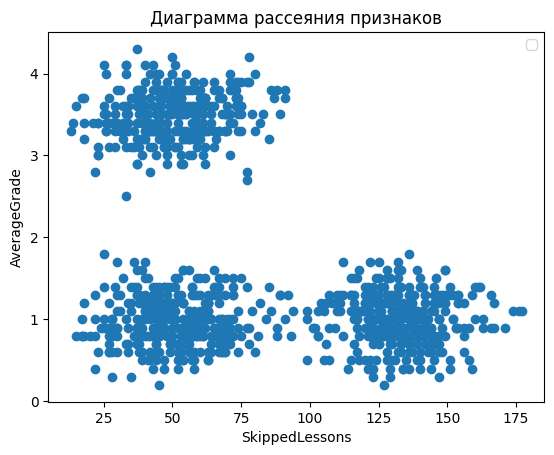

In [4]:
import matplotlib.pyplot as plt

plt.scatter(data_blobs['SkippedLessons'], data_blobs['AverageGrade'])
plt.xlabel('SkippedLessons')
plt.ylabel('AverageGrade')
plt.title('Диаграмма рассеяния признаков')
plt.legend()
plt.show()

### 1.4. Подготовка набора данных.

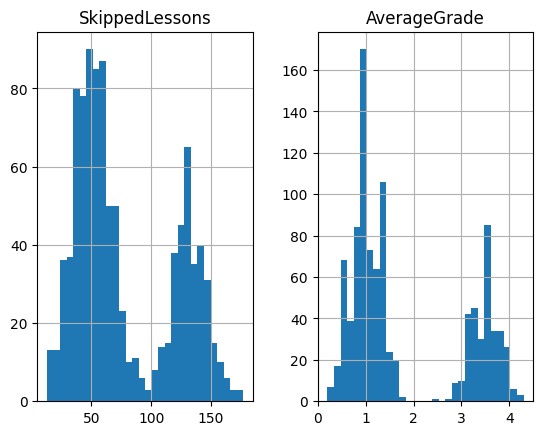

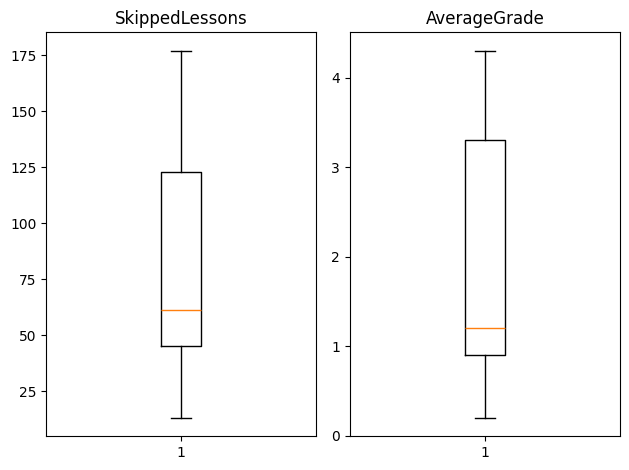

In [5]:
data_blobs[['SkippedLessons', 'AverageGrade']].hist(bins=30)
plt.show()

plt.subplot(1,2,1)
plt.boxplot(data_blobs['SkippedLessons'])
plt.title('SkippedLessons')

plt.subplot(1,2,2)
plt.boxplot(data_blobs['AverageGrade'])
plt.title('AverageGrade')

plt.tight_layout()
plt.show()

In [6]:
from sklearn.preprocessing import StandardScaler

X_blobs = data_blobs[['SkippedLessons', 'AverageGrade']]
print(X_blobs[:5])

scaler = StandardScaler()
X_blobs_scaled = scaler.fit_transform(X_blobs)
X_blobs_scaled_tf = pd.DataFrame(X_blobs_scaled, columns=['SkippedLessons', 'AverageGrade'])
print('\n', X_blobs_scaled_tf.head())
print(X_blobs_scaled_tf.describe())

   SkippedLessons  AverageGrade
0           130.0           1.1
1            54.0           0.5
2            58.0           1.0
3           107.0           0.9
4            42.0           1.2

    SkippedLessons  AverageGrade
0        1.260267     -0.590256
1       -0.576892     -1.086200
2       -0.480200     -0.672913
3        0.704285     -0.755570
4       -0.866970     -0.507598
       SkippedLessons  AverageGrade
count    1.000000e+03  1.000000e+03
mean     9.947598e-17 -6.394885e-17
std      1.000500e+00  1.000500e+00
min     -1.567991e+00 -1.334171e+00
25%     -7.944506e-01 -7.555704e-01
50%     -4.076802e-01 -5.075985e-01
75%      1.091055e+00  1.228205e+00
max      2.396405e+00  2.054778e+00


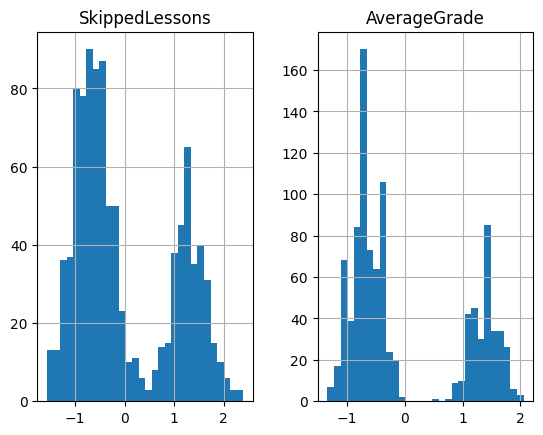

In [7]:
X_blobs_scaled_tf.hist(bins=30)
plt.show()

## 2. K-Means

### 2.1. Проведение исследования оптимального количества кластеров методов локтя.

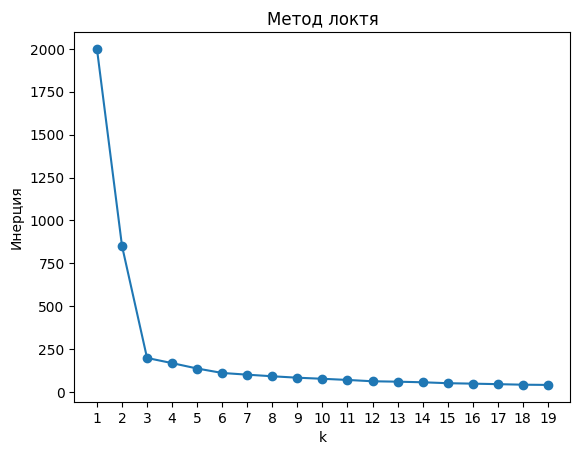

In [8]:
from sklearn.cluster import KMeans

inertia = []

for k in range(1, 20):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X_blobs_scaled_tf)
    inertia.append(model.inertia_)

plt.plot(range(1, 20), inertia, marker='o')
plt.title("Метод локтя")
plt.xlabel("k")
plt.xticks(range(1, 20))
plt.ylabel("Инерция")
plt.show()

### 2.2. Проведение исследования оптимального количества кластеров методом силуэта.

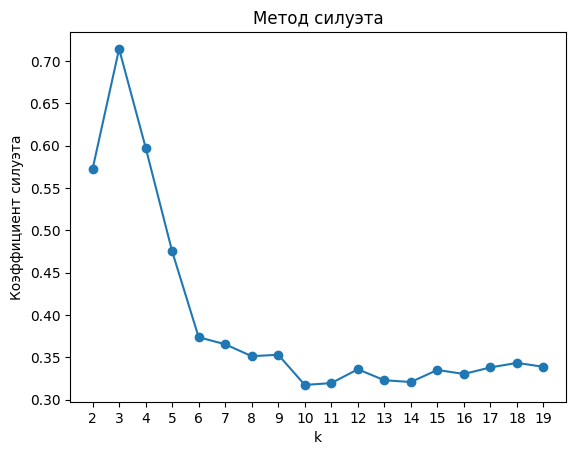

In [9]:
from sklearn.metrics import silhouette_score

sil_scores = []

for k in range(2, 20):
    model = KMeans(n_clusters=k, random_state=42)
    labels = model.fit_predict(X_blobs_scaled_tf)
    sil_scores.append(silhouette_score(X_blobs_scaled_tf, labels))

plt.plot(range(2, 20), sil_scores, marker='o')
plt.title("Метод силуэта")
plt.xlabel("k")
plt.xticks(range(2, 20))
plt.ylabel("Коэффициент силуэта")
plt.show()

### 2.3. Проведение кластеризации алгоритмом K-means, с выбранным оптимальным количеством кластеров.
### 2.4. Построение диаграммы рассеяния результатов кластеризации с выделением разным цветом разных кластеров.
k=3

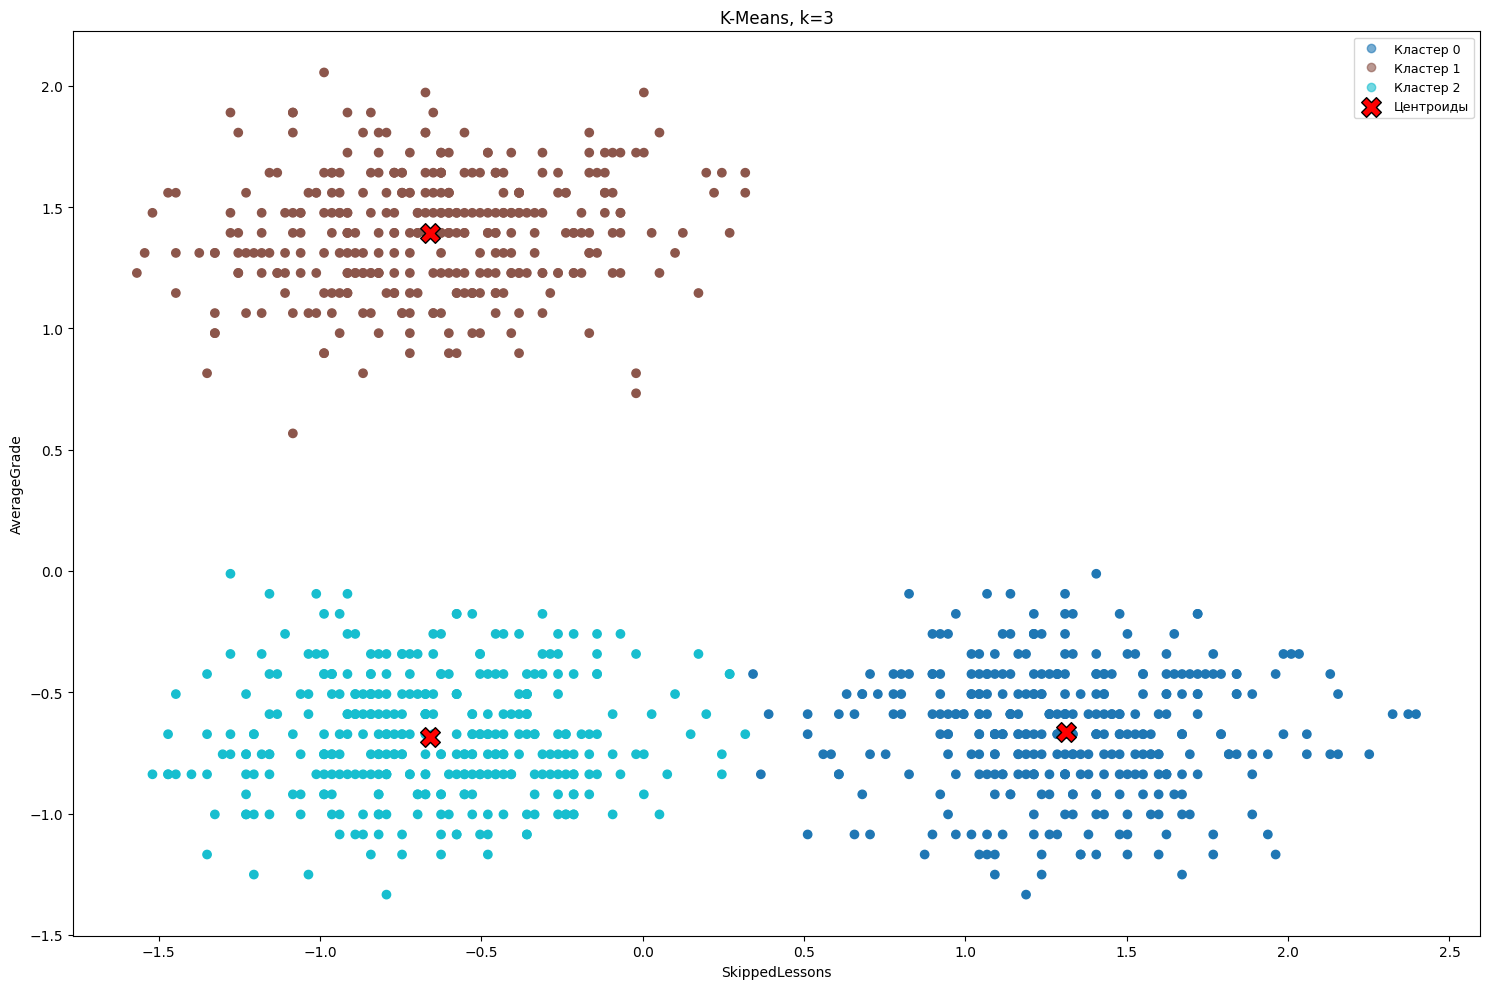

In [10]:
k_opt = 3
kmeans = KMeans(n_clusters=k_opt, random_state=42)
labels = kmeans.fit_predict(X_blobs_scaled_tf)
centroids = kmeans.cluster_centers_

fig, axes = plt.subplots(figsize=(15, 10))
scatter = plt.scatter(X_blobs_scaled_tf['SkippedLessons'], X_blobs_scaled_tf['AverageGrade'], c=labels, cmap='tab10')
centroid_marker = plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200, edgecolors='black', label='Центроиды')
handles, _ = scatter.legend_elements(prop="colors", alpha=0.6)
cluster_legend = [f"Кластер {i}" for i in range(k_opt)]
plt.title(f'K-Means, k={k_opt}')
plt.xlabel('SkippedLessons')
plt.ylabel('AverageGrade')
plt.legend(handles=[*handles, centroid_marker], labels=[*cluster_legend, 'Центроиды'], fontsize=9, loc='best')
plt.tight_layout()
plt.show()

### 2.5. Построение диаграмму Вороного для результатов кластеризации.

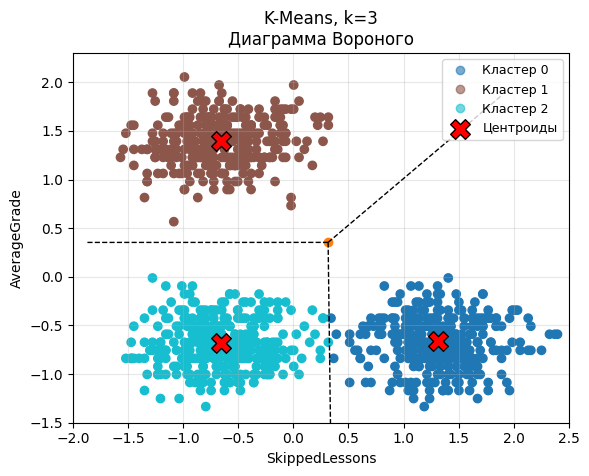

In [11]:
from scipy.spatial import Voronoi, voronoi_plot_2d
import numpy as np

vor = Voronoi(centroids)
voronoi_plot_2d(vor)
scatter = plt.scatter(X_blobs_scaled[:, 0], X_blobs_scaled[:, 1], c=labels, cmap='tab10')
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200, edgecolors='black', zorder=5)
plt.title(f'K-Means, k={k_opt}\nДиаграмма Вороного')
plt.xlabel('SkippedLessons')
plt.ylabel('AverageGrade')
plt.xlim(-2, 2.5)
plt.ylim(-1.5, 2.3)
plt.grid(True, alpha=0.3)
handles, _ = scatter.legend_elements(prop="colors", alpha=0.6)
cluster_legend = [f"Кластер {i}" for i in range(k_opt)]
plt.legend(handles=[*handles, centroid_marker], labels=[*cluster_legend, 'Центроиды'], fontsize=9, loc='best')
plt.show()

### 2.6. Выводы о разделении кластеров и успешности применения кластеризации K-means к набору данных.

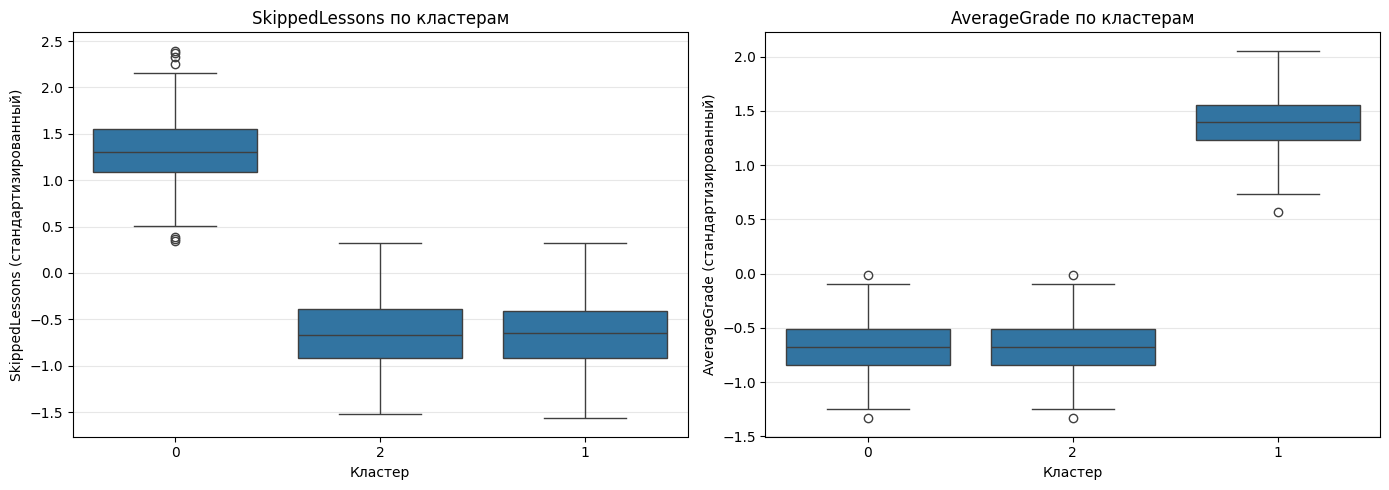

In [12]:
import seaborn as sns

k_opt = 3

df_plot = X_blobs_scaled_tf.copy()
df_plot['cluster'] = labels
df_plot['cluster'] = df_plot['cluster'].astype(str)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='cluster', y='SkippedLessons', data=df_plot, ax=axes[0])
axes[0].set_title('SkippedLessons по кластерам')
axes[0].set_xlabel('Кластер')
axes[0].set_ylabel('SkippedLessons (стандартизированный)')
axes[0].grid(alpha=0.3, axis='y')

sns.boxplot(x='cluster', y='AverageGrade', data=df_plot, ax=axes[1])
axes[1].set_title('AverageGrade по кластерам')
axes[1].set_xlabel('Кластер')
axes[1].set_ylabel('AverageGrade (стандартизированный)')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


### 2.7. Рассчет количества точек, среднее, СКО, минимум и максимум. Сопоставление результатов с построенными графиками.

In [13]:
df_temp = X_blobs_scaled_tf.copy()
df_temp['cluster'] = labels
pd.set_option('display.width', 1000)

stats = df_temp.groupby('cluster').agg({
    'SkippedLessons': ['count', 'mean', 'std', 'min', 'max'],
    'AverageGrade': ['count', 'mean', 'std', 'min', 'max']
})

print(stats)

        SkippedLessons                                         AverageGrade                                        
                 count      mean       std       min       max        count      mean       std       min       max
cluster                                                                                                            
0                  334  1.312594  0.362706  0.341687  2.396405          334 -0.662272  0.255168 -1.334171 -0.011655
1                  326 -0.658458  0.377707 -1.567991  0.317514          326  1.392759  0.245243  0.566946  2.054778
2                  340 -0.658086  0.367516 -1.519645  0.317514          340 -0.684825  0.245642 -1.334171 -0.011655


## 3.DBSCAN

### 3.1. Подбор параметров алгоритма DBSCAN.

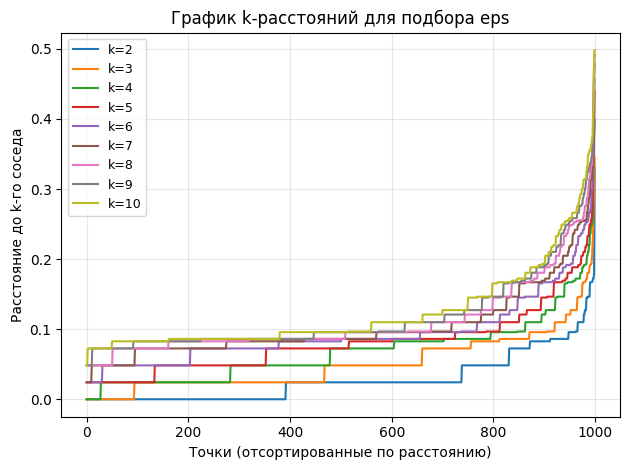

In [14]:
from sklearn.neighbors import NearestNeighbors

for k in range(2, 11):
    neight = NearestNeighbors(n_neighbors=k)
    neight.fit(X_blobs_scaled_tf)

    distances, _ = neight.kneighbors(X_blobs_scaled_tf)
    distances = np.sort(distances[:, -1])

    plt.plot(distances, label=f'k={k}')

plt.xlabel('Точки (отсортированные по расстоянию)')
plt.ylabel(f'Расстояние до k-го соседа')
plt.title('График k-расстояний для подбора eps')
plt.legend(loc='best', fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

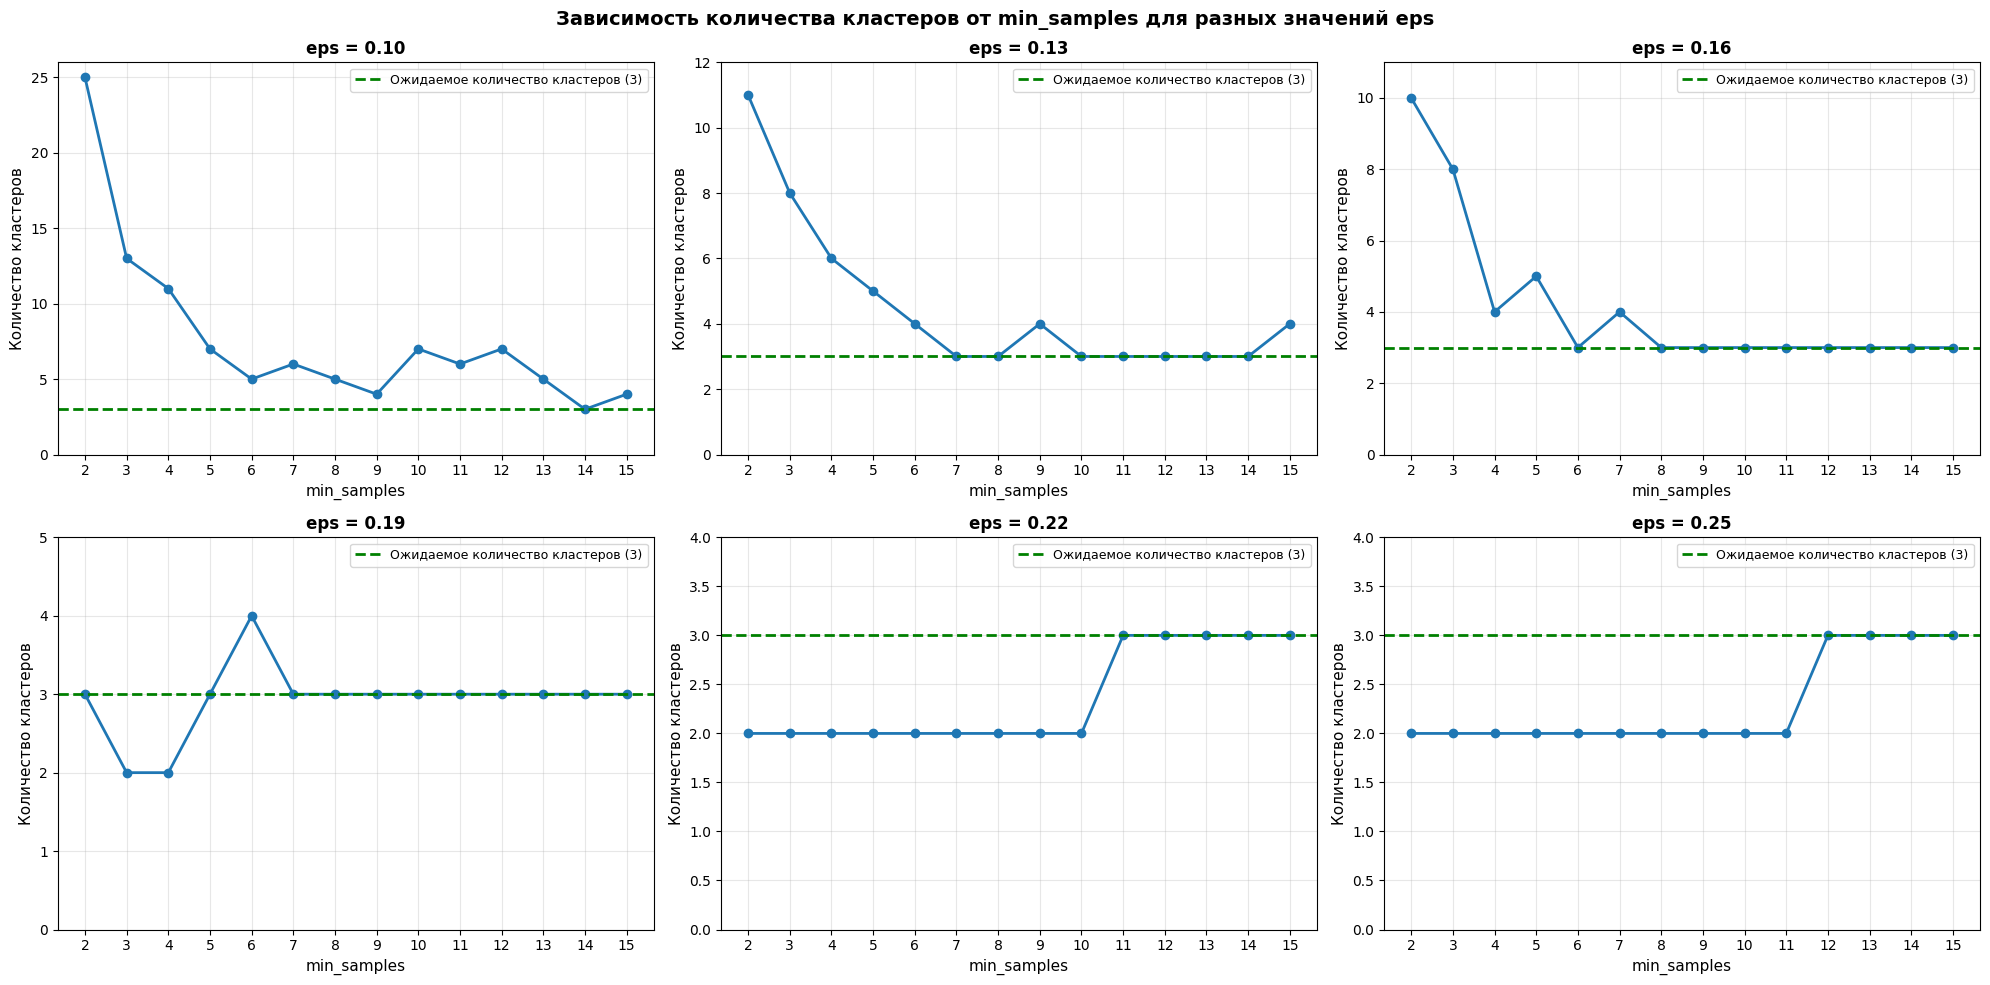

In [15]:
from sklearn.cluster import DBSCAN

eps_values = np.arange(0.1, 0.26, 0.03)
results = {}
min_samples_values = list(range(2, 16))

for min_samp in min_samples_values:
    results[min_samp] = {}
    for eps in eps_values:
        db = DBSCAN(eps=eps, min_samples=min_samp)
        labels = db.fit_predict(X_blobs_scaled_tf)
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise = list(labels).count(-1)
        results[min_samp][eps] = {'clusters': n_clusters, 'noise': noise}


fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.ravel()

for idx, eps in enumerate(eps_values):
    cluster_values = [results[min_s][eps]['clusters'] for min_s in min_samples_values]
    
    axes[idx].plot(min_samples_values, cluster_values, marker='o', linewidth=2, markersize=6)
    axes[idx].axhline(y=3, color='green', linestyle='--', linewidth=2, label='Ожидаемое количество кластеров (3)')
    axes[idx].set_xlabel('min_samples', fontsize=11)
    axes[idx].set_ylabel('Количество кластеров', fontsize=11)
    axes[idx].set_title(f'eps = {eps:.2f}', fontsize=12, fontweight='bold')
    axes[idx].grid(alpha=0.3)
    axes[idx].set_xticks(min_samples_values)
    axes[idx].set_ylim(0, max(cluster_values) + 1)
    axes[idx].legend(fontsize=9)
    
plt.suptitle('Зависимость количества кластеров от min_samples для разных значений eps', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


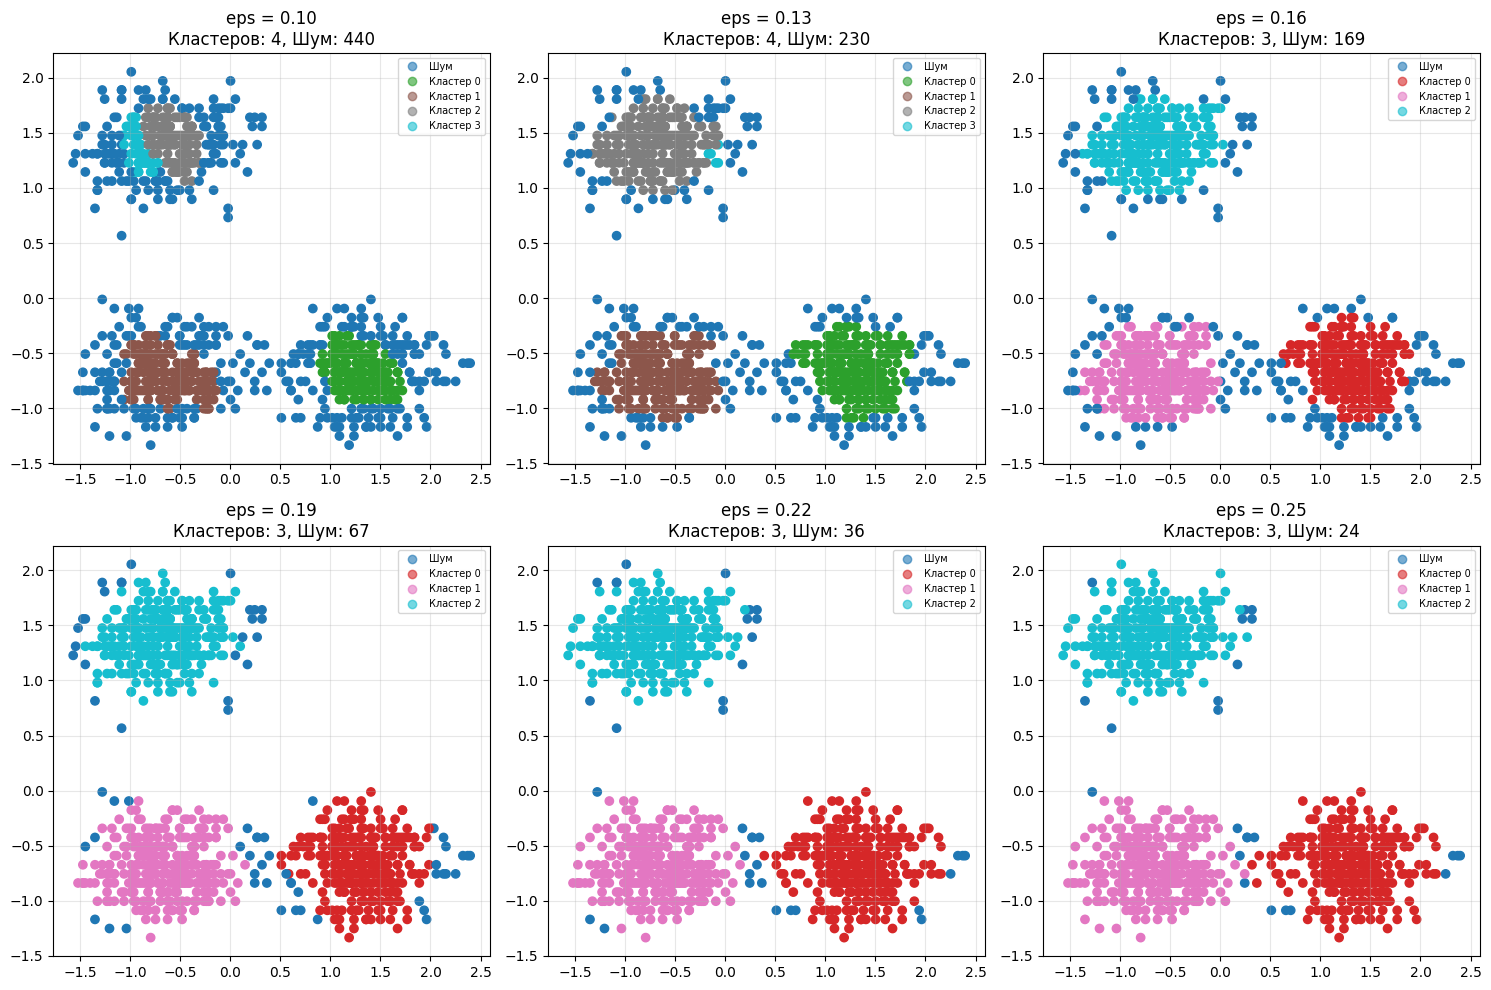

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for i, eps in enumerate(eps_values):
    db = DBSCAN(eps=eps, min_samples=15)
    labels = db.fit_predict(X_blobs_scaled)
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)

    scatter = axes[i].scatter(X_blobs_scaled[:, 0], X_blobs_scaled[:, 1], c=labels, cmap='tab10')
    
    axes[i].set_title(f'eps = {eps:.2f}\nКластеров: {n_clusters}, Шум: {n_noise}')
    axes[i].grid(alpha=0.3)
    
    handles, _ = scatter.legend_elements(prop="colors", alpha=0.6)

    unique_labels = sorted(set(labels))
    labels_legend = []
    for label in unique_labels:
        if label == -1:
            labels_legend.append("Шум")
        else:
            labels_legend.append(f"Кластер {label}")
    
    if len(labels_legend) <= 10:
        axes[i].legend(handles, labels_legend, fontsize=7, loc='best')
    else:
        axes[i].legend([f"Всего кластеров: {n_clusters}"], fontsize=8, loc='upper right')
        
plt.tight_layout()
plt.show()


## 4. Иерархическая кластеризация

### 4.1. Проведение иерархической кластеризацию, подобрав параметр linkage. Построение дендрограммы.

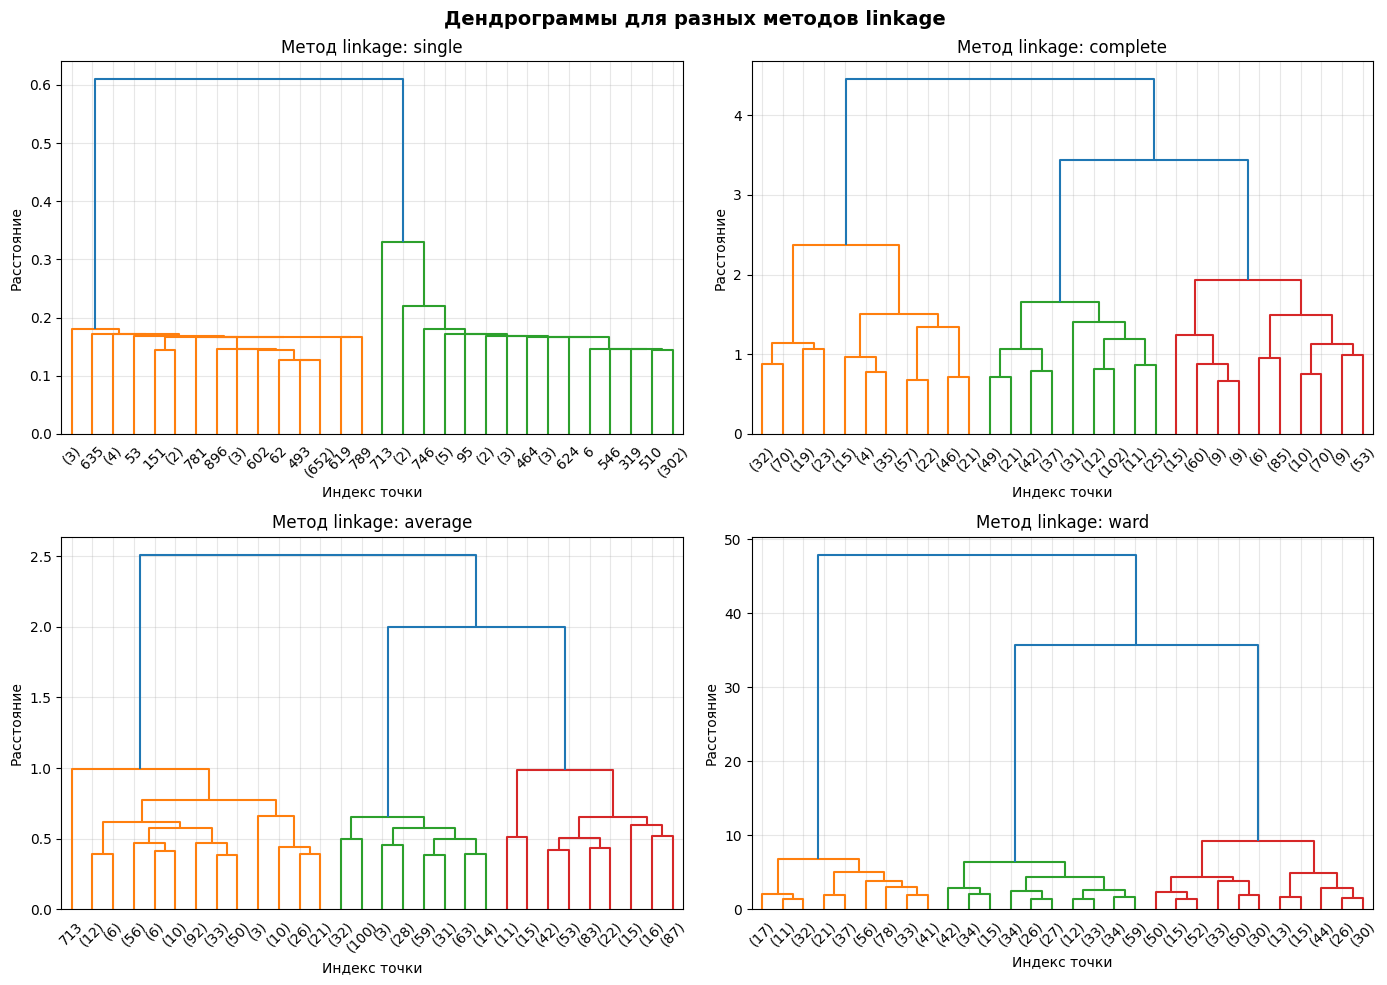

In [17]:
from scipy.cluster.hierarchy import dendrogram, linkage

linkage_methods = ['single', 'complete', 'average', 'ward']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()
for idx, method in enumerate(linkage_methods):
    try:
        Z = linkage(X_blobs_scaled_tf, method=method)
        dendro_data = dendrogram(Z, no_plot=True)
        
        dendrogram(Z, ax=axes[idx], truncate_mode='lastp', p=30)
        axes[idx].set_title(f'Метод linkage: {method}')
        axes[idx].set_xlabel('Индекс точки')
        axes[idx].set_ylabel('Расстояние')
        axes[idx].grid(alpha=0.3)
    except Exception as e:
        axes[idx].text(0.5, 0.5, f'Ошибка:\n{str(e)}', ha='center', va='center', transform=axes[idx].transAxes)
        axes[idx].set_title(f'Метод: {method}')

plt.suptitle('Дендрограммы для разных методов linkage', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

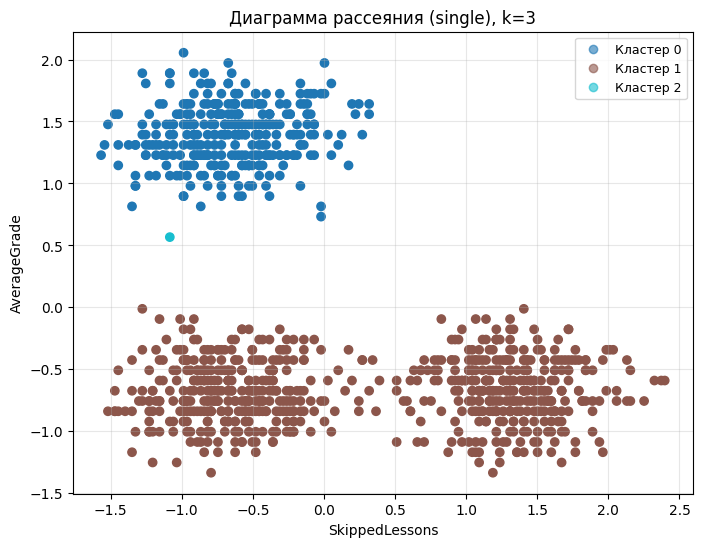

In [27]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=3, linkage='single')
labels = hc.fit_predict(X_blobs_scaled_tf)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_blobs_scaled_tf.iloc[:, 0], X_blobs_scaled_tf.iloc[:, 1], c=labels, cmap='tab10')

handles, _ = scatter.legend_elements(prop="colors", alpha=0.6)
labels_legend = [f"Кластер {i}" for i in range(3)]
plt.legend(handles, labels_legend, fontsize=9, loc='best')

plt.title(f'Диаграмма рассеяния (single), k=3')
plt.xlabel('SkippedLessons')
plt.ylabel('AverageGrade')
plt.grid(alpha=0.3)
plt.show()

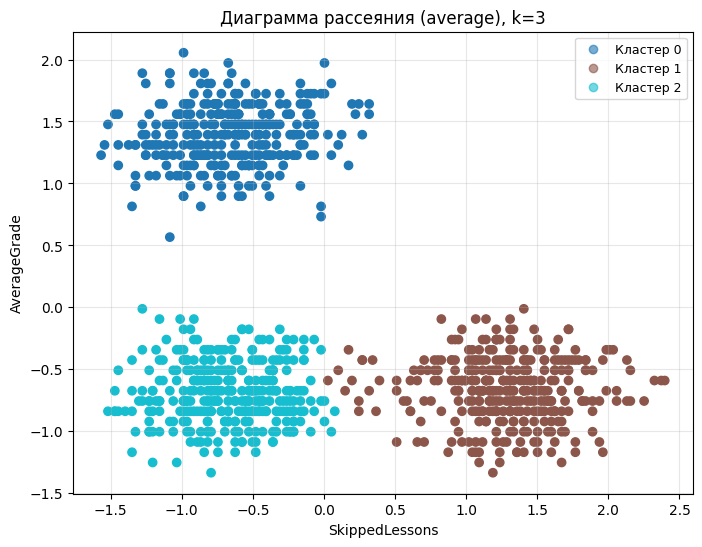

In [28]:
hc = AgglomerativeClustering(n_clusters=3, linkage='average')
labels = hc.fit_predict(X_blobs_scaled_tf)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_blobs_scaled_tf.iloc[:, 0], X_blobs_scaled_tf.iloc[:, 1], c=labels, cmap='tab10')

handles, _ = scatter.legend_elements(prop="colors", alpha=0.6)
labels_legend = [f"Кластер {i}" for i in range(3)]
plt.legend(handles, labels_legend, fontsize=9, loc='best')
plt.title(f'Диаграмма рассеяния (average), k=3')
plt.xlabel('SkippedLessons')
plt.ylabel('AverageGrade')
plt.grid(alpha=0.3)
plt.show()

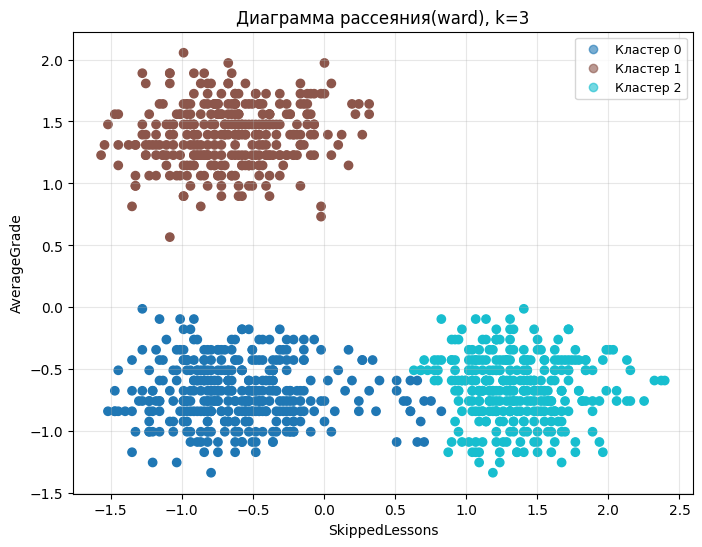

In [29]:
hc = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels = hc.fit_predict(X_blobs_scaled_tf)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_blobs_scaled_tf.iloc[:, 0], X_blobs_scaled_tf.iloc[:, 1], c=labels, cmap='tab10')

handles, _ = scatter.legend_elements(prop="colors", alpha=0.6)
labels_legend = [f"Кластер {i}" for i in range(3)]
plt.legend(handles, labels_legend, fontsize=9, loc='best')

plt.title(f'Диаграмма рассеяния(ward), k=3')
plt.xlabel('SkippedLessons')
plt.ylabel('AverageGrade')
plt.grid(alpha=0.3)
plt.show()

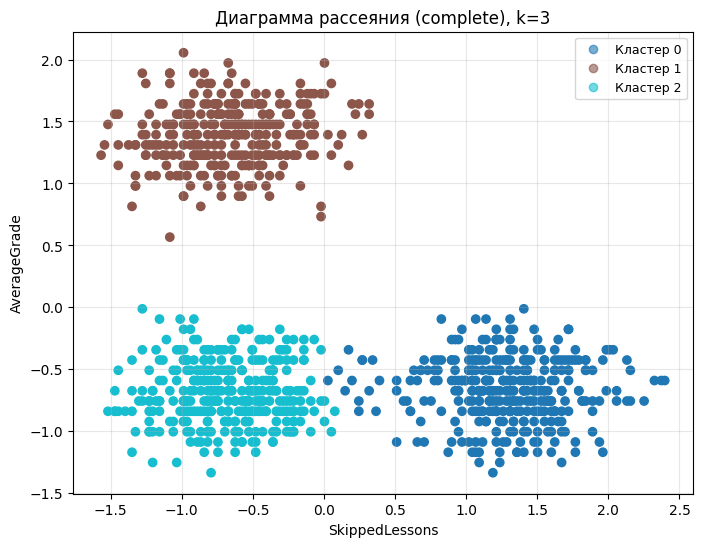

In [31]:
hc = AgglomerativeClustering(n_clusters=3, linkage='complete')
labels = hc.fit_predict(X_blobs_scaled_tf)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_blobs_scaled_tf.iloc[:, 0], X_blobs_scaled_tf.iloc[:, 1], c=labels, cmap='tab10')

handles, _ = scatter.legend_elements(prop="colors", alpha=0.6)
labels_legend = [f"Кластер {i}" for i in range(3)]
plt.legend(handles, labels_legend, fontsize=9, loc='best')
plt.title(f'Диаграмма рассеяния (complete), k=3')
plt.xlabel('SkippedLessons')
plt.ylabel('AverageGrade')
plt.grid(alpha=0.3)
plt.show()

In [22]:
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import fcluster

linkage_methods = ['single', 'complete', 'average', 'ward']
results = {}

for method in linkage_methods:
    Z = linkage(X_blobs_scaled_tf, method=method)
    labels = fcluster(Z, t=3, criterion='maxclust')
    
    score = silhouette_score(X_blobs_scaled_tf, labels)
    results[method] = score
    
    print(f'{method}: силуэт = {score:.3f}')

single: силуэт = 0.324
complete: силуэт = 0.710
average: силуэт = 0.710
ward: силуэт = 0.699


In [23]:
from sklearn.metrics import silhouette_score

eps_values = np.arange(0.19, 0.26, 0.01) 
min_samples_values = list(range(12, 16))

best_score = -1
best_params = {}
results = {}

for eps in eps_values:
    for min_samp in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samp)
        labels = dbscan.fit_predict(X_blobs_scaled_tf)
        
        mask_noise = labels != -1
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = sum(labels == -1)
        
        if n_clusters > 1 and mask_noise.sum() > 0:
            score = silhouette_score(X_blobs_scaled_tf[mask_noise], labels[mask_noise])
        else:
            score = -1
        
        results[(eps, min_samp)] = {
            'score': score,
            'clusters': n_clusters,
            'noise': n_noise
        }
        
        if score > best_score:
            best_score = score
            best_params = {
                'eps': eps,
                'min_samples': min_samp,
                'clusters': n_clusters,
                'noise': n_noise
            }

print(f"   eps = {best_params['eps']:.2f}")
print(f"   min_samples = {best_params['min_samples']}")
print(f"   Коэффициент силуэта = {best_score:.3f}")
print(f"   Количество кластеров = {best_params['clusters']}")
print(f"   Шумовых точек = {best_params['noise']}")


   eps = 0.19
   min_samples = 15
   Коэффициент силуэта = 0.742
   Количество кластеров = 3
   Шумовых точек = 67


In [24]:
kmeans = KMeans(n_clusters=3, random_state=42)
labels_kmeans = kmeans.fit_predict(X_blobs_scaled_tf)
score_kmeans = silhouette_score(X_blobs_scaled_tf, labels_kmeans)

dbscan = DBSCAN(eps=0.19, min_samples=15)
labels_dbscan = dbscan.fit_predict(X_blobs_scaled_tf)

mask_noise = labels_dbscan != -1
X_no_noise = X_blobs_scaled_tf[mask_noise]
labels_no_noise = labels_dbscan[mask_noise]
score_dbscan = silhouette_score(X_no_noise, labels_no_noise)

hc = AgglomerativeClustering(n_clusters=3, linkage='complete')
labels_hc = hc.fit_predict(X_blobs_scaled_tf)
score_hc = silhouette_score(X_blobs_scaled_tf, labels_hc)

print(f"K-Means:           {score_kmeans:.3f}")
print(f"DBSCAN:            {score_dbscan:.3f} (без учёта {mask_noise.sum() - len(X_blobs_scaled_tf)} шумовых точек)")
print(f"Hierarchical (complete/average): {score_hc:.3f}")

K-Means:           0.714
DBSCAN:            0.742 (без учёта -67 шумовых точек)
Hierarchical (complete/average): 0.710
